# **Clasificación de péptidos antimicrobianos**

Profesor: Dr. Irvin Hussein López-Nava

Materia: Reconocimiento de Patrones

Alumna: Jazmín Alejandra Martínez Guerrero

## **Obtención de los datos**

La muestra positiva (los péptidos antimicrobianos) se obtuvo de https://aps.unmc.edu/downloads. 
*2024 natural antimicrobial peptides (AMPs) with known activity (3306 entries)*.

La muestra negativa (los péptidos no antimibrobianos) se obtuvo de https://www.uniprot.org/uniprotkb
Y filtré aquellos que tenían de 1-200 aminoácidos (180,269 datos)


## **Lectura de los datos**


**Datos positivos**

In [1]:
# Función para leer los datos positivos (los que tienen actividad antimicrobiana)

def parse_fasta_positive(file_path):
    sequences = {}
    with open(file_path, 'r') as file:
        current_id = ""
        for line in file:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
                if current_id.startswith("Your search"):
                    current_id = ""
                    continue
                sequences[current_id] = ""
            elif current_id:
                sequences[current_id] += line
    return sequences

In [2]:
positives_raw = parse_fasta_positive("positive.txt")
print(type(positives_raw))
print(positives_raw)
print(len(positives_raw))

<class 'dict'>
{'AP00001': 'GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV', 'AP00002': 'YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY', 'AP00003': 'DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSVKCFCKRQC', 'AP00004': 'NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC', 'AP00005': 'VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK', 'AP00006': 'GNNRPVYIPQPRPPHPRI', 'AP00007': 'GNNRPVYIPQPRPPHPRL', 'AP00008': 'RLCRIVVIRVCR', 'AP00009': 'RFRPPIRRPPIRPPFYPPFRPPIRPPIFPPIRPPFRPPLGPFP', 'AP00010': 'RRIRPRPPRLPRPRPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPL', 'AP00011': 'WNPFKELERAGQRVRDAVISAAPAVATVGQAAAIARG', 'AP00012': 'GLFDIIKKIAESI', 'AP00013': 'GLFDIIKKIAESF', 'AP00014': 'GLLDIVKKVVGAFGSL', 'AP00015': 'GLFDIVKKVVGALGSL', 'AP00016': 'GLFDIVKKVVGAIGSL', 'AP00017': 'GLFDIVKKVVGTLAGL', 'AP00018': 'GLFDIVKKVVGAFGSL', 'AP00019': 'GLFDIAKKVIGVIGSL', 'AP00020': 'GLFDIVKKIAGHIAGSI', 'AP00021': 'GLFDIVKKIAGHIASSI', 'AP00022': 'GLFDIVKKIAGHIVSSI', 'AP00023': 'AACARFIDDFCDTLTPNIYRPRDNGQRCYAVNGHRCDFTVFNTNNGGNPIRASTPNCKTVLRTAANRCPTGGRGKIN

**Datos negativos**

In [3]:
# Función para leer los datos negativos (los que no tienen actividad antimicrobiana)

def parse_fasta_negative(filepath):
    sequences = {}
    
    with open(filepath, 'r') as file:
        content = file.read()
        
    blocks = content.strip().split('>')
    
    for block in blocks:
        if not block:
            continue
            
        lines = block.splitlines()
        header = lines[0]
        
        seq_id = header.split('|')[1] if '|' in header else header.split()[0]
        sequence = "".join(lines[1:]).strip()
        
        if sequence:
            sequences[seq_id] = sequence
            
    return sequences

In [4]:
negatives_raw = parse_fasta_negative("negative.fasta")
print(type(negatives_raw))
print(len(negatives_raw))

<class 'dict'>
180264


## **Filtrado de datos**

Se tienen que filtrar los datos de la muestra negativa porque son muchos más (180264) que los positivos (3306), además tenemos que fijar que el número de secuencias sean parecidas entre ambas bases (sino al algoritmo podría clasificar según a la longitud de la secuencia)

Primero debemos de asegurarnos de que los peptidos tengan toda su secuencia de aminoácidos, porque puede suceder que aparezcan X (lo cual significa que el aminoácido es desconocido) y si tenemos un aminoácido desconcido, no podemos calcular sus características

In [5]:
print(len(positives_raw))
print(len(negatives_raw))

3306
180264


Tenemos 3306 datos positivos y 180264 negativos

In [6]:
def filter_canonical_peptides(peptide_dict):
    valid_aas = set("ACDEFGHIKLMNPQRSTVWY")
    return {k: v for k, v in peptide_dict.items() if set(v.upper()).issubset(valid_aas)}

positives_raw = filter_canonical_peptides(positives_raw)
negatives_raw = filter_canonical_peptides(negatives_raw)
print(len(positives_raw))
print(len(negatives_raw))

3306
179073


Tenemos 3306 datos positivos y 179073 negativos, todos con sus aminoácidos conocidos

In [7]:
# Para conocer la longitud de las secuencias de nuestras bases vamos a ver los cuartiles de longitud de la cantidad de aminoacidos por peptido
import statistics

def get_peptide_length_quartiles(peptide_dict):
    lengths = [len(seq) for seq in peptide_dict.values()]
    
    if not lengths:
        return {}
        
    if len(lengths) < 4:
        raise ValueError("Insufficient data")
        
    quartiles = statistics.quantiles(lengths, n=4)

    return {
        'Q1': quartiles[0],
        'Q2': quartiles[1],
        'Q3': quartiles[2],
        'Min': min(lengths),
        'Max' : max(lengths)
    }

In [8]:
print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_raw)}")

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 89.0, 'Q2': 127.0, 'Q3': 161.0, 'Min': 2, 'Max': 200}


Se filtran los negativos con un muestreo que ayude a tener una distribución de longitud similar a la de los positivos.

In [9]:
# Esta función cuenta cuántos aminoácidos tiene cada peptido en positivos, 
# y luego muestrea los negativos con longitudes iguales para que la distribución sea la misma
# En el muestro NO se permite que haya intersección entre positivos y negativos
# Para esto primero se excluyen los positivos que están en el conjunto de negativos
# Para asegurarnos de que haya la misma cantidad en ambos conjuntos, dejamos "deficit"

import random
from collections import defaultdict

def match_peptide_distribution(positives_dict, negatives_dict):
    pos_sequences = set(positives_dict.values())
    
    target_distribution = defaultdict(int)
    for seq in positives_dict.values():
        target_distribution[len(seq)] += 1
        
    negatives_by_length = defaultdict(list)
    seen_sequences = set()
    
    for k, v in negatives_dict.items():
        if v not in seen_sequences and v not in pos_sequences:
            seen_sequences.add(v)
            negatives_by_length[len(v)].append((k, v))
            
    sampled_negatives = {}
    unused_negatives = []
    deficit = 0
    
    for length, target_count in target_distribution.items():
        available = negatives_by_length.get(length, [])
        
        if target_count <= len(available):
            sampled_items = random.sample(available, target_count)
            sampled_negatives.update(sampled_items)
            
            sampled_keys = set(k for k, v in sampled_items)
            unused_negatives.extend([(k, v) for k, v in available if k not in sampled_keys])
        else:
            sampled_negatives.update(available)
            deficit += target_count - len(available)
            
    if deficit > 0:
        if deficit <= len(unused_negatives):
            extra_samples = random.sample(unused_negatives, deficit)
            sampled_negatives.update(extra_samples)
        else:
            sampled_negatives.update(unused_negatives)
            
    return sampled_negatives

In [10]:
random.seed(26)
negatives_filtered = match_peptide_distribution(positives_raw, negatives_raw)

print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_filtered)}")

print(len(positives_raw))
print(len(negatives_filtered))

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
3306
3306


Se agregan descriptores para los peptidos, los cuales usaremos para el modelo de clasificación.
Para esto se utilizará la función calculate_all() los detalles se pueden consultar en https://modlamp.org/modlamp.html


In [11]:
#pip install modlamp

In [12]:
from modlamp.descriptors import GlobalDescriptor

def calculate_global_descriptors(peptide_dict):
    peptide_ids = list(peptide_dict.keys())
    sequences = list(peptide_dict.values())
    
    descriptor_instance = GlobalDescriptor(sequences)
    descriptor_instance.calculate_all()
    
    features_dict = {}
    for i, seq_id in enumerate(peptide_ids):
        features_dict[seq_id] = descriptor_instance.descriptor[i]
        
    return features_dict

In [13]:
positives_descriptors = calculate_global_descriptors(positives_raw)
negatives_descriptors = calculate_global_descriptors(negatives_filtered)

In [14]:
# Se combinan los diccionarios para tener toda la información junta 
def combine_peptide_data(sequence_dict, descriptor_dict):
    combined = {}
    for k, v in sequence_dict.items():
        if k in descriptor_dict:
            combined[k] = {
                'sequence': v,
                'features': descriptor_dict[k]
            }
    return combined

positives_complete = combine_peptide_data(positives_raw, positives_descriptors)
negatives_complete = combine_peptide_data(negatives_filtered, negatives_descriptors)

In [15]:
# Combinamos toda la información en un solo dataframe

import pandas as pd

# Los nombres se obtuvieron de https://modlamp.org/modlamp.html
feature_cols = ['Length', 'MW', 'Charge', 'Charge_Density', 'pI', 'Instability', 'Aromaticity', 'Aliphatic', 'BomanInd', 'HydrophRatio']

df_pos = pd.DataFrame.from_dict(positives_complete, orient='index')
df_pos['type'] = 1

df_neg = pd.DataFrame.from_dict(negatives_complete, orient='index')
df_neg['type'] = 0

df = pd.concat([df_pos, df_neg]).reset_index().rename(columns={'index': 'id'})
df[feature_cols] = pd.DataFrame(df['features'].tolist(), index=df.index)
df = df.drop(columns=['features'])
df.columns = df.columns.str.lower()

In [16]:
# Con 1 los que son antimicrobianos y con 0 los que no
df.head(4)

,id,sequence,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,33.0,3180.71,3.988,0.001254,10.683594,7.272727,0.030303,95.151515,0.231818,0.515152
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,34.0,3877.48,4.985,0.001286,11.458496,84.155882,0.176471,40.000000,1.198235,0.205882
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,54.0,5947.71,2.878,0.000484,8.126221,57.074074,0.111111,27.037037,1.954444,0.314815
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,49.0,5613.26,1.881,0.000335,7.916870,16.722449,0.122449,22.040816,2.433673,0.306122


**Descriptores** 
La información se obtuvo de: https://academic.oup.com/bioinformatics/article/33/17/2753/3796392

- **Length**: Longitud de la secuencia
- **MW**: Peso Molecular
- **Chrage**: Carga neta. Carga neta del péptido a pH 7.0.
- **Charge_Density**: Densidad de carga. Es la relación entre la carga neta del péptido y su peso molecular (carga / MW)
- **pI**: Punto isoeléctrico. pH al cual la carga neta del péptido es cero. 
- **Instability**:  Índice de Inestabilidad. Estima la estabilidad in vivo de una proteína a partir de la composición de sus dipéptidos.
- **Aromaticity**: Aromaticidad. Frecuencia relativa de los aminoácidos aromáticos en la secuencia. Los residuos aromáticos son fenilalanina (F), triptófano (W) y tirosina (Y). 
- **Aliphatic**: Índice Alifático. Indicador de la termoestabilidad de proteínas globulares. Un índice alifático más alto sugiere que la proteína es más estable y capaz de mantener su estructura frente a temperaturas elevadas. (https://pubmed.ncbi.nlm.nih.gov/7462208/)
- **BomanInd**: Índice de Boman. Evalúa el potencial de unión a proteínas (en kcal/mol), y se usa para estimar perfiles de interacción y solubilidad.
- **HydrophRatio**: Razón de hidrofobicidad. Calcula la frecuencia relativa de los aminoácidos hidrofóbicos A, C, F, I, L, M y V en la secuencia. 

## **Análisis exploratorio**

In [17]:
df.columns
# Se espera que charge_density esté relacionada con mw y charge

Index(['id', 'sequence', 'type', 'length', 'mw', 'charge', 'charge_density',
       'pi', 'instability', 'aromaticity', 'aliphatic', 'bomanind',
       'hydrophratio'],
      dtype='str')

### **Correlación**

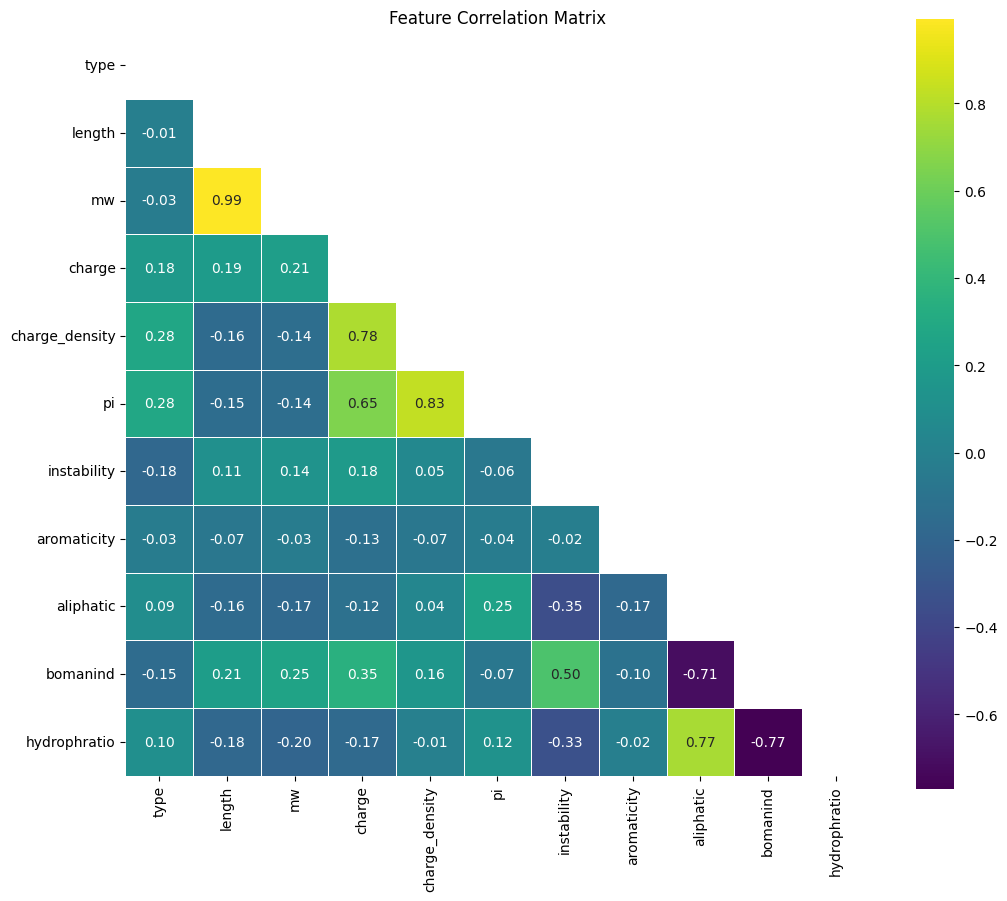

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='viridis', 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5
)
plt.title('Feature Correlation Matrix')
plt.show()

Podemos observar alta correlación entre variables como longitud de la secuencia y el peso molecular (0.99), la densidad de la carga y la carga (0.78), el punto isoeléctrico y la densidad de carga (0.83), y su es alifatico o hidrofobico (0.77).
Por otro lado, las correlaciones inversas más altas son entre el índice de Boman y si es alifatico (-0.71), y el índice de Boman y la hidrofobicidad (-0.77).

### **Normalidad**

Se evalúa la normalidad de cada variable mediante inspección visual con gráficas Q-Q y el test de Kolmogorov-Smirnov (K-S), que es más adecuado para muestras grandes

       Feature  KS_stat  p-value  Is_Normal
        length   0.1724   0.0000      False
            mw   0.1626   0.0000      False
        charge   0.1235   0.0000      False
charge_density   0.0425   0.0000      False
            pi   0.0990   0.0000      False
   instability   0.0634   0.0000      False
   aromaticity   0.0915   0.0000      False
     aliphatic   0.0380   0.0000      False
      bomanind   0.0218   0.0037      False
  hydrophratio   0.0348   0.0000      False


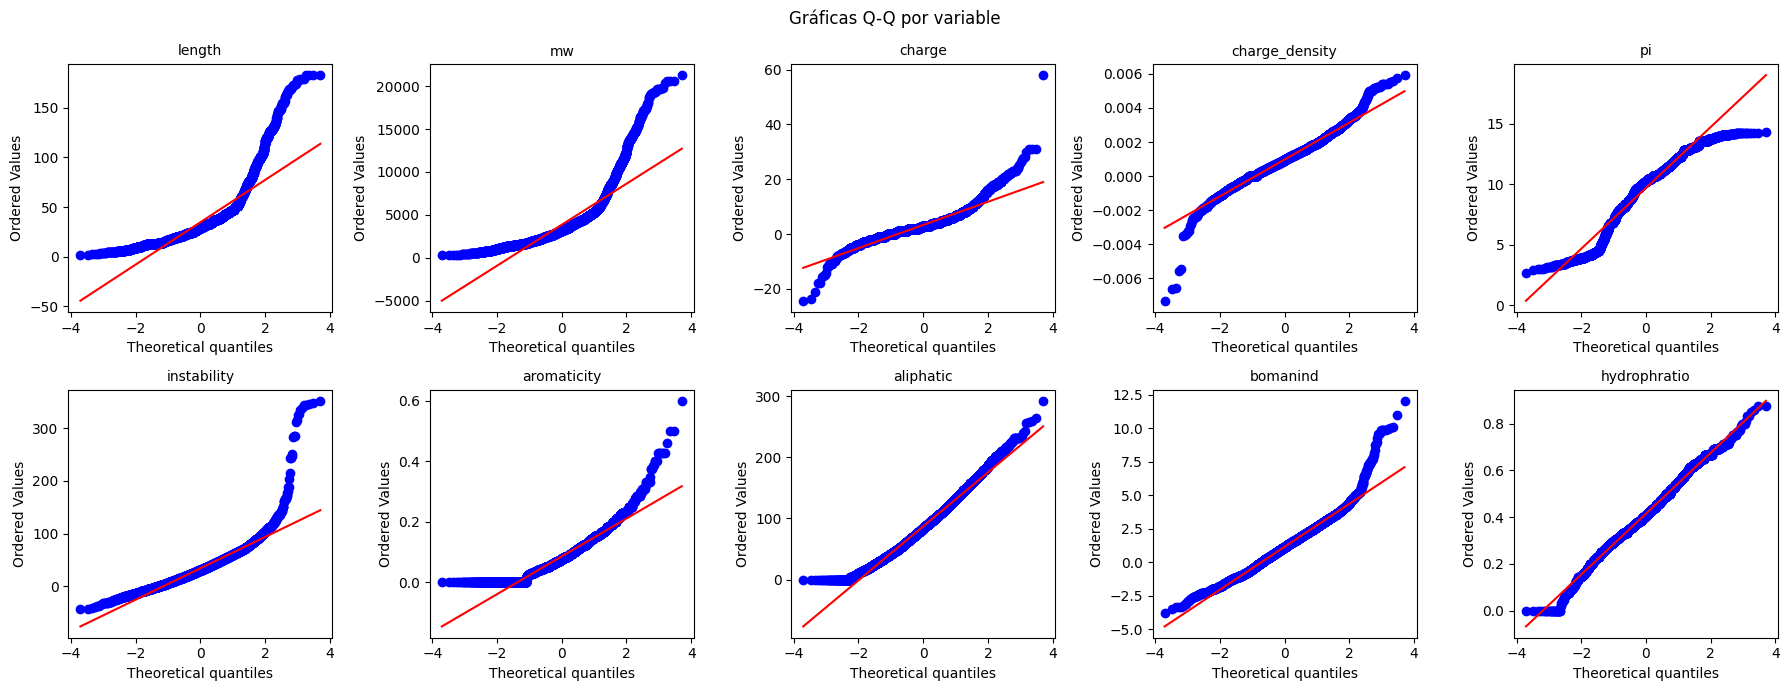

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

numeric_cols = df.drop(columns=['id', 'sequence', 'type']).apply(pd.to_numeric)

# --- Test de Kolmogorov-Smirnov (adecuado para n > 2000) ---
ks_results = []
for col in numeric_cols.columns:
    data = numeric_cols[col].dropna().values
    # K-S contra una normal con los parámetros de la muestra
    stat, p_value = stats.kstest(data, 'norm',
                                  args=(data.mean(), data.std(ddof=1)))
    ks_results.append({
        'Feature'   : col,
        'KS_stat'   : round(stat, 4),
        'p-value'   : round(p_value, 4),
        'Is_Normal' : p_value > 0.05
    })

ks_df = pd.DataFrame(ks_results)
print(ks_df.to_string(index=False))

# --- Gráficas Q-Q para inspección visual ---
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols.columns):
    ax = axes[idx]
    data = numeric_cols[col].dropna()
    stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(col, fontsize=10)
for ax in axes[len(numeric_cols.columns):]:
    ax.set_visible(False)
plt.suptitle('Gráficas Q-Q por variable', fontsize=12)
plt.tight_layout()
plt.show()

Tanto el test K-S como las gráficas Q-Q muestran desviaciones sistemáticas respecto a la distribución normal en todas las variables: colas pesadas, asimetría y bimodalidad son frecuentes. Bajo este diagnóstico, el supuesto de que cada atributo $A_i$ dado la clase $c_j$ sigue una distribución gaussiana $\mathcal{N}(\mu, \sigma^2)$, requerido por el Gaussian Naive Bayes, no se sostiene. Por ello se descarta dicho modelo y se opta por discretizar las variables continuas, permitiendo el uso del Clasificador Bayesiano Semi-Ingenuo con tablas de probabilidad condicional discretas.

## **Discretización de los datos**

In [20]:
df.columns

Index(['id', 'sequence', 'type', 'length', 'mw', 'charge', 'charge_density',
       'pi', 'instability', 'aromaticity', 'aliphatic', 'bomanind',
       'hydrophratio'],
      dtype='str')

In [21]:
import pandas as pd

def fit_discretization(df_train):
    """
    Aprende los bordes de los bins de cuantilización ÚNICAMENTE sobre
    el conjunto de entrenamiento y los devuelve en un diccionario.
    Esto evita data leakage: los bordes del test se calculan con datos
    del train, no del test.
    """
    continuous_features = [
        'mw', 'charge', 'charge_density', 'pi',
        'instability', 'aromaticity', 'aliphatic',
        'bomanind', 'hydrophratio'
    ]
    bins_dict = {}
    for col in continuous_features:
        if col not in df_train.columns:
            continue
        try:
            _, bins = pd.qcut(df_train[col], q=4, duplicates='drop', retbins=True)
            bins_dict[col] = bins
        except ValueError:
            pass
    return bins_dict


def apply_discretization(df, bins_dict):
    """
    Aplica los bordes aprendidos (bins_dict) a cualquier dataframe
    (train o test). Usa pd.cut con los bordes fijos del train para
    garantizar que ambos conjuntos comparten el mismo espacio discreto.
    """
    df_out = df.copy()
    for col, bins in bins_dict.items():
        if col not in df_out.columns:
            continue
        num_bins = len(bins) - 1
        box_labels = [f"{col}{i+1}" for i in range(num_bins)]
        df_out[col] = pd.cut(
            df_out[col],
            bins=bins,
            labels=box_labels,
            include_lowest=True
        )
    return df_out


In [22]:
# Vista previa de la discretización sobre el dataframe completo
# (solo con fines ilustrativos; en el pipeline de evaluación los bins
#  se aprenden exclusivamente sobre cada fold de entrenamiento)
preview_bins = fit_discretization(df)
test_disc = apply_discretization(df, preview_bins)
print(test_disc.head(4))


        id                                           sequence  type  length  \
0  AP00001                  GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV     1    33.0   
1  AP00002                 YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY     1    34.0   
2  AP00003  DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...     1    54.0   
3  AP00004  NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC     1    49.0   

    mw   charge   charge_density   pi   instability   aromaticity   aliphatic  \
0  mw3  charge3  charge_density3  pi3  instability1  aromaticity1  aliphatic3   
1  mw3  charge3  charge_density3  pi4  instability4  aromaticity4  aliphatic1   
2  mw4  charge3  charge_density2  pi2  instability4  aromaticity3  aliphatic1   
3  mw4  charge2  charge_density2  pi1  instability2  aromaticity3  aliphatic1   

    bomanind   hydrophratio  
0  bomanind2  hydrophratio4  
1  bomanind3  hydrophratio1  
2  bomanind3  hydrophratio1  
3  bomanind4  hydrophratio1  


### **Modelo elegido: SNBC**

Este ejercicio tiene por objetivo realizar una clasificación binaria de los péptidos, en si son antimicrobianos o si no lo son. Por lo tanto, los modelos Dinámicos y Temporales, de Clasificación Jerárquica y Multidimensionales y Multietiqueta quedan descartados.

Para nuestro próposito podrían servirnos los siguientes:
- Clasificador Bayesiano Ingenuo (NBC): El cual asume independencia condicional entre todos los atributos dada la clase
- Gaussian Naive Bayes: Los atributos siguen una distribución gaussiana
- TAN (Tree Augmented Bayesian Classifier): Incorpora dependencias entre atributos formando una estructura de árbol dirigido entre ellos
- BAN (Bayesian Network augmented Bayesian Classifier): Relaja la restricción de árbol del TAN, permitiendo que los atributos formen un grafo acíclico dirigido (DAG)
- Clasificadores Bayesianos Semi-ingenuos (SNBC): Buscan mejorar el NBC eliminando atributos irrelevantes o uniendo atributos dependientes para mantener la eficiencia


### **Modelo elegido: SNBC**
Se eligió el modelo SNBC porque se quiere priorizar la simplicidad del modelo para poder tener una mejor interpretación. Además, el Gaussian Naive Bayes queda descartado porque las variables no se distribuyen de forma normal y el NBC porque los atributos no son independientes. 

## **Formalización matemática del modelo elegido (SNBC)**

### **1. Definición de Variables**

* **Variable de Clase ($C$):** Variable aleatoria discreta que representa la actividad biológica del péptido.
    * $C \in \{0, 1\}$
    * $C = 1$ indica que el péptido es antimicrobiano.
    * $C = 0$ indica que no es antimicrobiano.

* **Espacio de Atributos Original ($\mathbf{A}$):**

  El conjunto de atributos predictores comprende exclusivamente las características fisicoquímicas calculadas:

  $$\mathbf{A} = (A_1, \dots, A_{10}) = (\text{length},\ \text{mw},\ \text{charge},\ \text{charge\_density},\ \text{pi},\ \text{instability},\ \text{aromaticity},\ \text{aliphatic},\ \text{bomanind},\ \text{hydrophratio})$$

* **Espacio de Atributos Optimizado ($\mathbf{A'}$):**

  $$\mathbf{A'} = (A'_1, \dots, A'_n), \quad n \leq 10$$

  Este espacio se obtiene tras las dos fases de mejora estructural descritas a continuación.



### **2. Mejora Estructural**

El Clasificador Bayesiano Semi-Ingenuo (SNBC) extiende el Clasificador Bayesiano Ingenuo (NBC) mediante la eliminación o combinación de atributos que violan el supuesto de independencia condicional. El procedimiento sigue el Algoritmo 4.1 del libro *Probabilistic Graphical Models* de Luis Enrique Sucar.

**Fase 1 — Eliminación de nodos:**

- Se elimina la variable `length` por redundancia con `mw`: dado que el peso molecular es la suma de los pesos de los aminoácidos, ambas variables comparten prácticamente la misma información ($I(\text{length}; \text{mw}) \approx 0.99$ en escala de correlación). Conservar ambas viola el espíritu del NBC sin aportar información adicional.

- Para cada atributo $A_j$ restante se calcula la Información Mutua con la clase:

  $$I(A_j; C) = \sum_{a_j} \sum_{c} P(A_j = a_j, C = c) \log_2 \frac{P(A_j = a_j, C = c)}{P(A_j = a_j)\, P(C = c)}$$

  Los atributos con $I(A_j; C) < \varepsilon$ se eliminan por ser poco informativos para la predicción de la clase.

**Fase 2 — Combinación de nodos:**

- Para cada par de atributos restantes $(A_j, A_k)$ se calcula la Información Mutua Condicional dada la clase:

  $$I(A_j; A_k \mid C) = \sum_{c} P(C = c) \sum_{a_j} \sum_{a_k} P(A_j = a_j, A_k = a_k \mid C = c) \log_2 \frac{P(A_j = a_j, A_k = a_k \mid C = c)}{P(A_j = a_j \mid C = c)\, P(A_k = a_k \mid C = c)}$$

- Si $I(A_j; A_k \mid C) > \omega$, los atributos no son condicionalmente independientes dada la clase. En ese caso se combinan en un nuevo atributo $A_{jk}$ cuyo dominio es el producto cartesiano de los dominios de $A_j$ y $A_k$.

Tras esta transformación, los atributos del conjunto optimizado $\mathbf{A'}$ satisfacen la propiedad de independencia condicional:

$$P(A'_1, A'_2, \dots, A'_n \mid C) = \prod_{j=1}^{n} P(A'_j \mid C)$$



### **3. Parámetros del Modelo ($\Theta$)**

El aprendizaje consiste en estimar las probabilidades a partir del conjunto de entrenamiento discretizado mediante Máxima Verosimilitud.

* **Probabilidades a priori de la clase:**

  $$P(C = c_i) \sim \frac{N_i}{N}$$

  donde $N_i$ es el número de instancias de la clase $c_i$ y $N$ el total de instancias en el conjunto de entrenamiento.

* **Probabilidades condicionales de los atributos:**

  $$P(A'_j = v_k \mid C = c_i) \sim \frac{N_{jki}}{N_i}$$

  donde $N_{jki}$ es el número de instancias de la clase $c_i$ en las que el atributo $A'_j$ toma el valor $v_k$.



### **4. Regla de Decisión (Inferencia)**

Dado un vector de características $\mathbf{a'} = (a'_1, \dots, a'_n)$, el clasificador asigna la clase $c^*$ que maximiza la probabilidad posterior. Dado que la evidencia marginal $P(\mathbf{a'})$ es constante respecto a la clase, la regla de decisión se reduce a:

$$c^* = \arg\max_{c_i \in \{0,1\}} \left[ P(C = c_i) \prod_{j=1}^{n} P(A'_j = a'_j \mid C = c_i) \right]$$

En la implementación se trabaja en espacio logarítmico para evitar underflow numérico:

$$c^* = \arg\max_{c_i} \left[ \log P(C = c_i) + \sum_{j=1}^{n} \log P(A'_j = a'_j \mid C = c_i) \right]$$



### **5. Suavizado de Laplace**

Si algún intervalo discretizado no aparece en los datos de entrenamiento para cierta clase, su probabilidad estimada por máxima verosimilitud sería cero, colapsando el producto posterior a cero independientemente de los demás atributos. Para evitar este problema se aplica el suavizado de Laplace, que asigna una pseudocuenta de $\alpha = 1$ a cada valor posible:

$$P(A'_j = v_k \mid C = c_i) = \frac{N_{jki} + 1}{N_i + K_j}$$

donde:
* $N_{jki}$: número de instancias de la clase $c_i$ en las que $A'_j = v_k$.
* $N_i$: número total de instancias de la clase $c_i$ en el conjunto de entrenamiento.
* $K_j$: número total de valores posibles (bins) del atributo $A'_j$.

De este modo, cada valor tiene probabilidad estrictamente mayor que cero, garantizando que la inferencia pueda evaluar cualquier secuencia nueva en validación cruzada.

In [23]:
test_disc.head(4)


,id,sequence,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,33.0,mw3,charge3,charge_density3,pi3,instability1,aromaticity1,aliphatic3,bomanind2,hydrophratio4
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,34.0,mw3,charge3,charge_density3,pi4,instability4,aromaticity4,aliphatic1,bomanind3,hydrophratio1
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,54.0,mw4,charge3,charge_density2,pi2,instability4,aromaticity3,aliphatic1,bomanind3,hydrophratio1
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,49.0,mw4,charge2,charge_density2,pi1,instability2,aromaticity3,aliphatic1,bomanind4,hydrophratio1


## **Modificación de la estructura**


In [24]:
import pandas as pd
import numpy as np

def calculate_mi(df, col1, col2):
    contingency = pd.crosstab(df[col1], df[col2], normalize=True)
    margin1 = contingency.sum(axis=1)
    margin2 = contingency.sum(axis=0)
    
    mi = 0.0
    for val1 in contingency.index:
        for val2 in contingency.columns:
            p_xy = contingency.loc[val1, val2]
            if p_xy > 0:
                p_x = margin1.loc[val1]
                p_y = margin2.loc[val2]
                mi += p_xy * np.log2(p_xy / (p_x * p_y))
    return mi

def calculate_cmi(df, col1, col2, target):
    cmi = 0.0
    p_z_dist = df[target].value_counts(normalize=True)
    
    for z in p_z_dist.index:
        df_z = df[df[target] == z]
        if len(df_z) == 0:
            continue
            
        p_z = p_z_dist[z]
        contingency_z = pd.crosstab(df_z[col1], df_z[col2], normalize=True)
        margin1_z = contingency_z.sum(axis=1)
        margin2_z = contingency_z.sum(axis=0)
        
        for val1 in contingency_z.index:
            for val2 in contingency_z.columns:
                p_xy_z = contingency_z.loc[val1, val2]
                if p_xy_z > 0:
                    p_x_z = margin1_z.loc[val1]
                    p_y_z = margin2_z.loc[val2]
                    cmi += p_z * p_xy_z * np.log2(p_xy_z / (p_x_z * p_y_z))
    return cmi

def structural_improvement(df, epsilon, omega):
    df_out = df.drop(columns=['id', 'sequence', 'length'], errors='ignore').copy()
    
    target = 'type'
    features = [col for col in df_out.columns if col != target]
    
    kept_features = []
    for a in features:
        mi_value = calculate_mi(df_out, a, target)
        if mi_value >= epsilon:
            kept_features.append(a)
        else:
            df_out = df_out.drop(columns=[a])
            
    features = kept_features.copy()
    processed = set()
    
    i = 0
    while i < len(features):
        a = features[i]
        if a in processed:
            i += 1
            continue
            
        j = i + 1
        while j < len(features):
            b = features[j]
            if b in processed:
                j += 1
                continue
                
            cmi_value = calculate_cmi(df_out, a, b, target)
            
            if cmi_value > omega:
                new_col = f"{a}_{b}"
                df_out[new_col] = df_out[a].astype(str) + "_" + df_out[b].astype(str)
                df_out = df_out.drop(columns=[a, b])
                
                features.append(new_col)
                processed.add(a)
                processed.add(b)
                break
                
            j += 1
        i += 1
        
    return df_out

## **Implementación del aprendizaje**

In [25]:
import pandas as pd
import numpy as np

def learn_snbc_laplace(df_train, class_col, features):
    model = {
        'priors': {},
        'likelihoods': {}
    }
    
    total_samples = len(df_train)
    class_counts = df_train[class_col].value_counts()
    num_classes = len(class_counts)
    
    for c in class_counts.index:
        model['priors'][c] = (class_counts[c] + 1) / (total_samples + num_classes)
        
    for feature in features:
        model['likelihoods'][feature] = {}
        unique_bins = df_train[feature].unique()
        k_bins = len(unique_bins)
        
        for c in class_counts.index:
            subset = df_train[df_train[class_col] == c]
            N_c = len(subset)
            feature_counts = subset[feature].value_counts()
            
            model['likelihoods'][feature][c] = {}
            
            for val in unique_bins:
                m = feature_counts.get(val, 0)
                smoothed_prob = (1 + m) / (k_bins + N_c)
                model['likelihoods'][feature][c][val] = smoothed_prob
                
    return model

## **Implementación de la inferencia**

In [26]:
import pandas as pd
import numpy as np

def inference_snbc_laplace(model, df_test, features):
    
    # Con Inferencia en escala logarítmica para evitar underflow numérico.

    predictions = []

    for _, row in df_test.iterrows():
        class_scores = {}

        for c in model['priors']:
            score = np.log(model['priors'][c])

            for feature in features:
                val = str(row[feature])
                feature_probs = model['likelihoods'][feature][c]

                if val in feature_probs:
                    prob = feature_probs[val]
                else:
                    prob = min(feature_probs.values())

                score += np.log(prob)

            class_scores[c] = score

        predicted_class = max(class_scores, key=class_scores.get)
        predictions.append(predicted_class)

    return predictions


## **Evaluación Experimental**

In [27]:
import time
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

def execute_snbc(df_raw, class_col, epsilon, omega, k=10):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=666)

    cv_results = {
        'accuracy'       : [],
        'sensitivity'    : [],
        'specificity'    : [],
        'f1'             : [],
        'mcc'            : [],
        'tp': [], 'tn': [], 'fp': [], 'fn': [],
        'training_time'  : [],
        'inference_time' : []
    }

    # Columnas base para parsear nombres de variables combinadas
    original_cols = [
        'mw', 'charge', 'charge_density', 'pi',
        'instability', 'aromaticity', 'aliphatic',
        'bomanind', 'hydrophratio'
    ]
    sorted_base_cols = sorted(original_cols, key=len, reverse=True)

    for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(df_raw, df_raw[class_col])):

        df_train_raw = df_raw.iloc[train_idx].copy()
        df_test_raw  = df_raw.iloc[test_idx].copy()

        # 1. Eliminar columnas no predictoras
        drop_cols = ['length', 'id', 'sequence']
        df_train_raw = df_train_raw.drop(columns=drop_cols, errors='ignore')
        df_test_raw  = df_test_raw.drop(columns=drop_cols,  errors='ignore')

        # 2. Discretización; los bins se aprenden solo sobre el train
        bins_dict = fit_discretization(df_train_raw)
        df_train_disc = apply_discretization(df_train_raw, bins_dict)
        df_test_disc  = apply_discretization(df_test_raw,  bins_dict)

        # 3. Mejora estructural (aprende solo del train)
        df_train_improved = structural_improvement(df_train_disc, epsilon, omega)
        final_features = [c for c in df_train_improved.columns if c != class_col]

        # 4. Reconstruir variables combinadas en el test
        for col in final_features:
            if col not in df_test_disc.columns:
                parts = []
                remaining = col
                while remaining:
                    matched = False
                    for bc in sorted_base_cols:
                        if remaining.startswith(bc):
                            parts.append(bc)
                            remaining = remaining[len(bc):]
                            if remaining.startswith('_'):
                                remaining = remaining[1:]
                            matched = True
                            break
                    if not matched:
                        break
                if parts:
                    df_test_disc[col] = df_test_disc[parts[0]].astype(str)
                    for part in parts[1:]:
                        df_test_disc[col] += '_' + df_test_disc[part].astype(str)

        df_test_improved = df_test_disc[df_train_improved.columns]

        # 5. Aprendizaje
        start_train = time.time()
        model = learn_snbc_laplace(df_train_improved, class_col, final_features)
        end_train = time.time()

        # 6. Inferencia
        start_infer = time.time()
        predictions = inference_snbc_laplace(model, df_test_improved, final_features)
        end_infer = time.time()

        y_test = df_test_improved[class_col].tolist()

        # 7. Métricas
        cm = confusion_matrix(y_test, predictions, labels=[1, 0])
        tp, fn, fp, tn = cm.ravel()

        acc  = (tp + tn) / (tp + tn + fp + fn)
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1   = (2 * prec * sens / (prec + sens)) if (prec + sens) > 0 else 0.0
        mcc_denom = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        mcc  = (tp*tn - fp*fn) / mcc_denom if mcc_denom > 0 else 0.0

        cv_results['accuracy'].append(acc)
        cv_results['sensitivity'].append(sens)
        cv_results['specificity'].append(spec)
        cv_results['f1'].append(f1)
        cv_results['mcc'].append(mcc)
        cv_results['tp'].append(tp)
        cv_results['tn'].append(tn)
        cv_results['fp'].append(fp)
        cv_results['fn'].append(fn)
        cv_results['training_time'].append(end_train - start_train)
        cv_results['inference_time'].append(end_infer - start_infer)

    return cv_results


In [28]:
k = 10

results = execute_snbc(df_raw=df, class_col='type', epsilon=0.01, omega=0.05, k=k)

mean_acc   = sum(results['accuracy'])    / k
mean_sens  = sum(results['sensitivity']) / k
mean_spec  = sum(results['specificity']) / k
mean_f1    = sum(results['f1'])          / k
mean_mcc   = sum(results['mcc'])         / k

total_tp   = sum(results['tp'])
total_tn   = sum(results['tn'])
total_fp   = sum(results['fp'])
total_fn   = sum(results['fn'])

mean_train_time = sum(results['training_time'])   / k
mean_infer_time = sum(results['inference_time'])  / k

print('=' * 45)
print('Resultados de validación cruzada (k=10)')
print('=' * 45)
print(f"  Accuracy     : {mean_acc:.4f}")
print(f"  Sensibilidad : {mean_sens:.4f}")
print(f"  Especificidad: {mean_spec:.4f}")
print(f"  F1-score     : {mean_f1:.4f}")
print(f"  MCC          : {mean_mcc:.4f}")
print('-' * 45)
print(f"  Total TP: {total_tp}   TN: {total_tn}")
print(f"  Total FP: {total_fp}   FN: {total_fn}")
print('-' * 45)
print(f"  Tiempo medio entrenamiento : {mean_train_time:.4f} s")
print(f"  Tiempo medio inferencia    : {mean_infer_time:.4f} s")
print('=' * 45)


Resultados de validación cruzada (k=10)
  Accuracy     : 0.7314
  Sensibilidad : 0.7284
  Especificidad: 0.7344
  F1-score     : 0.7304
  MCC          : 0.4636
---------------------------------------------
  Total TP: 2408   TN: 2428
  Total FP: 878   FN: 898
---------------------------------------------
  Tiempo medio entrenamiento : 0.0060 s
  Tiempo medio inferencia    : 0.0166 s


In [ ]:
len(df) # número de instancias

6612